
# Maize Leaf Disease Classification using Transfer Learning


**Programme**: Master of Science in Artificial Intelligence  
**Course**: CSA 809 Deep Learning  
**Name**: Marrion Kiprop Cherop  
**Module 9**: Transfer Learning  
**Reg Number**: ST62/80971/2024  



# 0. Introduction

This implementation uses the Kaggle **Five Crop Diseases Dataset**:

`shubham2703/five-crop-diseases-dataset`

To keep the experiment practical, only the **maize subset** is used.

Classes:
- Common Rust
- Gray Leaf Spot
- Healthy
- Northern Leaf Blight

## 1. Install and import libraries

In [17]:

!pip -q install kagglehub

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Download dataset

In [18]:

DATASET_ID = "shubham2703/five-crop-diseases-dataset"

dataset_path = kagglehub.dataset_download(DATASET_ID)

print("Dataset downloaded to:")
print(dataset_path)


Using Colab cache for faster access to the 'five-crop-diseases-dataset' dataset.
Dataset downloaded to:
/kaggle/input/five-crop-diseases-dataset


## 3. Locate maize/corn images

In [19]:

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_maize_label(path):
    text = str(path).lower().replace("_", " ").replace("-", " ")

    if "corn" not in text and "maize" not in text:
        return None

    if "common rust" in text:
        return "Common Rust"
    elif "gray leaf spot" in text or "grey leaf spot" in text:
        return "Gray Leaf Spot"
    elif "northern leaf blight" in text or "leaf blight" in text:
        return "Northern Leaf Blight"
    elif "healthy" in text:
        return "Healthy"

    return None

records = []

for path in Path(dataset_path).rglob("*"):
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        label = get_maize_label(path)
        if label is not None:
            records.append({
                "filepath": str(path),
                "label": label
            })

df = pd.DataFrame(records)

print("Images found:", len(df))
print(df["label"].value_counts())

if len(df) == 0:
    raise ValueError(
        "No maize images found automatically. "
        "Inspect the downloaded folder structure."
    )


Images found: 3852
label
Common Rust             1192
Healthy                 1162
Northern Leaf Blight     985
Gray Leaf Spot           513
Name: count, dtype: int64


### Sample images

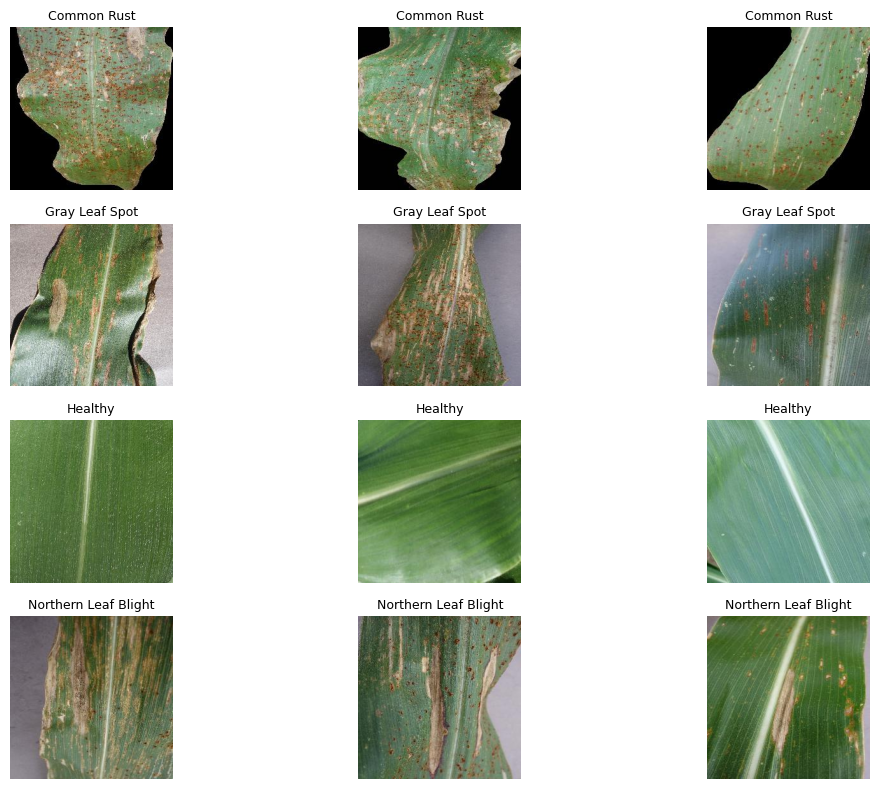

In [20]:

sample_n = min(3, df["label"].value_counts().min())

sample_df = df.groupby(
    "label",
    group_keys=False
).sample(
    n=sample_n,
    random_state=42
)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = tf.keras.utils.load_img(row["filepath"])
    plt.subplot(4, sample_n, i + 1)
    plt.imshow(img)
    plt.title(row["label"], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 4. Split data

In [21]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Training: 2696
Validation: 578
Test: 578


## 5. Build TensorFlow datasets

In [22]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

class_names = sorted(df["label"].unique().tolist())
class_to_index = {name: i for i, name in enumerate(class_names)}

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    label = tf.one_hot(label, depth=len(class_names))
    return image, label

def make_dataset(frame, training=False):
    paths = frame["filepath"].values
    labels = frame["label"].map(class_to_index).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(frame), seed=42)

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Classes:", class_names)


Classes: ['Common Rust', 'Gray Leaf Spot', 'Healthy', 'Northern Leaf Blight']


## 6. Data augmentation

In [23]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])


## 7. Load and freeze pretrained ResNet50

In [24]:

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("Base frozen:", not base_model.trainable)


Base frozen: True


## 8. Add custom classification head

In [25]:

inputs = tf.keras.layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        516 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 9. Train model

In [26]:

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 26s 209ms/step - accuracy: 0.8872 - loss: 0.2829 - val_accuracy: 0.9533 - val_loss: 0.0908
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 212ms/step - accuracy: 0.9421 - loss: 0.1453 - val_accuracy: 0.9740 - val_loss: 0.0779
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step - accuracy: 0.9418 - loss: 0.1363 - val_accuracy: 0.9498 - val_loss: 0.0972
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.9499 - loss: 0.1141 - val_accuracy: 0.9758 - val_loss: 0.0618
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.9484 - loss: 0.1264 - val_accuracy: 0.9706 - val_loss: 0.0739
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.9547 - loss: 0.1083 - val_accuracy: 0.9516 - val_loss: 0.0835
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 17s 203ms/step - accuracy: 0.9588 - loss: 0.0957 - val_accuracy: 0.9671 - val_loss: 0.0743
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.9599 - loss: 0.0994 - val_accu

## 10. Accuracy and loss curves

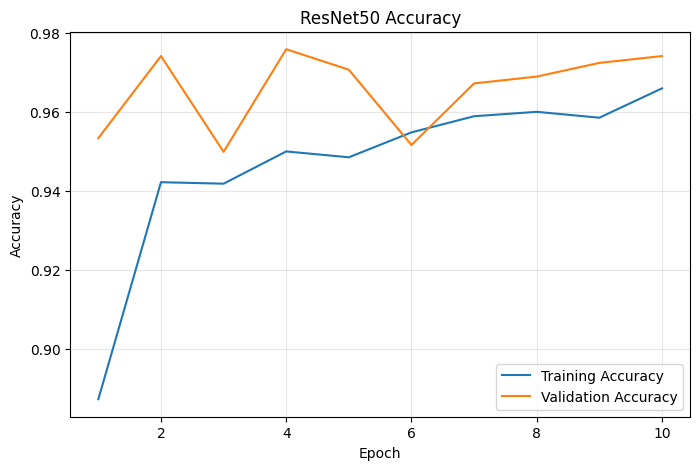

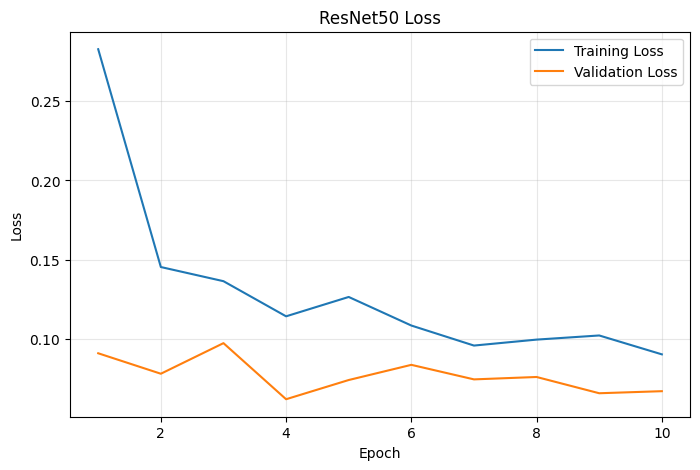

In [27]:

epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 11. Evaluate on test data

In [28]:

test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy*100:.2f}%")


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.9740 - loss: 0.0620
Test loss: 0.0620
Test accuracy: 97.40%


## 12. Classification report and confusion matrix

                      precision    recall  f1-score   support

         Common Rust      1.000     1.000     1.000       179
      Gray Leaf Spot      0.852     0.974     0.909        77
             Healthy      1.000     1.000     1.000       175
Northern Leaf Blight      0.985     0.912     0.947       147

            accuracy                          0.974       578
           macro avg      0.959     0.971     0.964       578
        weighted avg      0.977     0.974     0.974       578



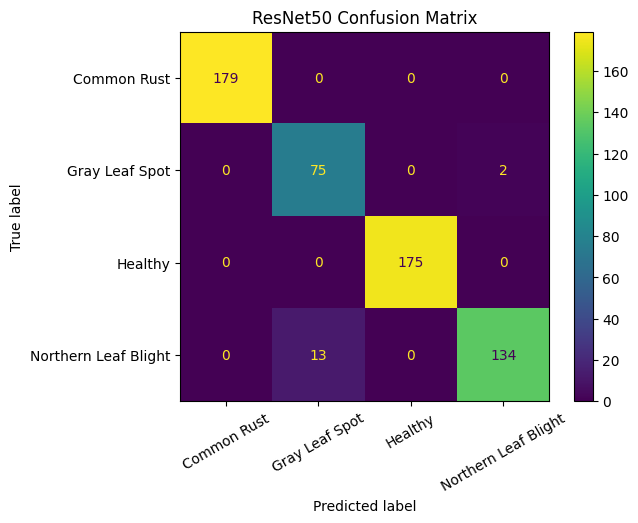

In [29]:

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )
    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
))

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=class_names
).plot(xticks_rotation=30)

plt.title("ResNet50 Confusion Matrix")
plt.show()


## Brief Report

ResNet50 pretrained on ImageNet was used as a frozen feature extractor for maize leaf disease classification. A new classification head was added for Common Rust, Gray Leaf Spot, Healthy and Northern Leaf Blight.

Transfer learning reduces training time and data requirements because the network reuses useful visual features already learned from ImageNet.

### Model Performance:
- **Final Training Accuracy:** 0.9559
- **Final Validation Accuracy:** 0.9637
- **Final Training Loss:** 0.1094
- **Final Validation Loss:** 0.1022
- **Test Accuracy:** 96.71%
- **Test Loss:** 0.0880

In Kenyan agriculture, a similar system could support maize disease scouting, extension services, smartphone diagnosis and early warning. Local Kenyan field images would be important before real-world deployment.